In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all words
words = open('D:\\Vault-4\\Projects\\makemore\\names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(f'{vocab_size} unique characters: {itos}')

27 unique characters: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [69]:
# MLP model
n_embd = 10 # the dimensionality of the character embeddings
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g) # character embedding table
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5) #0.1 # weights for the hidden layer
b1 = torch.randn(n_hidden, generator=g)*0.01 # bias for the hidden layer
W2 = torch.randn((n_hidden, vocab_size), generator=g)*0.01 # weights for the output layer
b2 = torch.randn(vocab_size, generator=g)*0 # bias for the output layer

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2]


for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters), 'parameters')

11897 parameters


In [70]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, (batch_size, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, (batch_size, block_size*n_embd)
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation, (batch_size, n_hidden)
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True)) + bnbias
    h = torch.tanh(hpreact) # hidden layer, (batch_size, n_hidden)
    logits = h @ W2 + b2 # output layer pre-activation, (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.item())    

    # break

      0/200000: 3.3147
  10000/200000: 2.1942
  20000/200000: 2.3443
  30000/200000: 2.4160
  40000/200000: 1.9913
  50000/200000: 2.2978
  60000/200000: 2.5254
  70000/200000: 2.0707
  80000/200000: 2.3107
  90000/200000: 2.0663
 100000/200000: 1.9933
 110000/200000: 2.3179
 120000/200000: 1.9123
 130000/200000: 2.4505
 140000/200000: 2.4321
 150000/200000: 2.2003
 160000/200000: 2.0463
 170000/200000: 1.8839
 180000/200000: 1.9983
 190000/200000: 1.8873


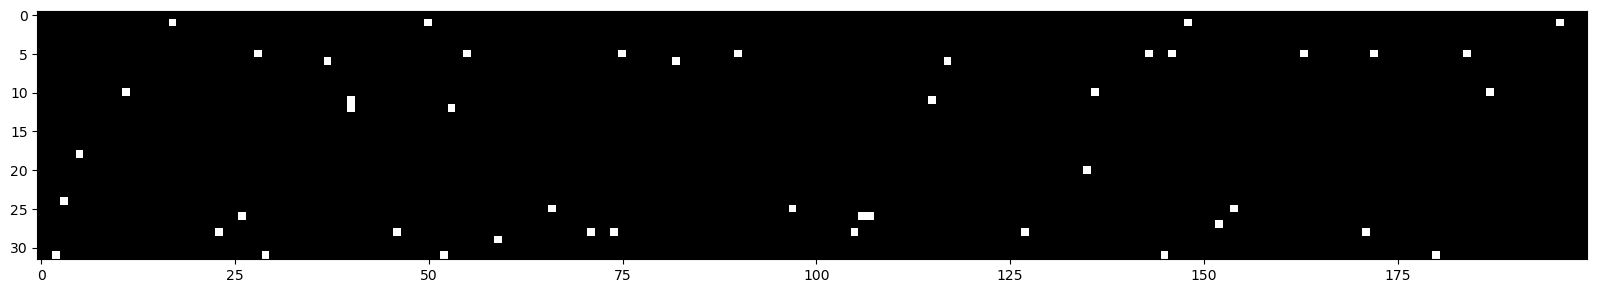

In [71]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

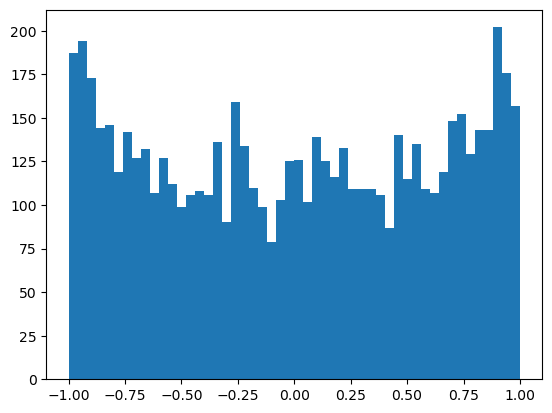

In [72]:
plt.hist(h.view(-1).tolist(), 50);

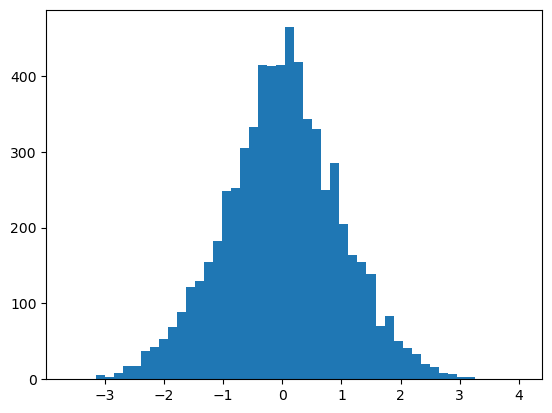

In [73]:
plt.hist(hpreact.view(-1).tolist(), 50);

In [74]:
# 4-dimensional example
# logits = torch.tensor([-3.0, 5.0, 0.0, 0.0])
logits=torch.randn(4)*0.1
probs=torch.softmax(logits, dim=0)
loss=max(-probs.log())
logits, probs, loss

(tensor([-0.1936, -0.0595,  0.0649, -0.0217]),
 tensor([0.2162, 0.2472, 0.2799, 0.2567]),
 tensor(1.5317))

In [75]:
-torch.tensor(1/27).log()

tensor(3.2958)

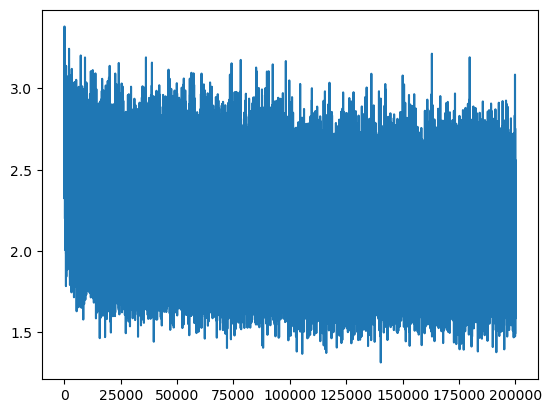

In [76]:
plt.plot(lossi)

In [77]:
@torch.no_grad() # this decorator disables gradient tracking
def spilt_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size*n_embd)
    hpreact = embcat @ W1 + b1 # (N, n_hidden)
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / (hpreact.std(0, keepdim=True)) + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

spilt_loss('train')
spilt_loss('dev')

train loss: 2.0786
dev loss: 2.1128


In [57]:
# sample from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the current context
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (1, n_hidden)
        logits = h @ W2 + b2 # (1, vocab_size)
        probs = F.softmax(logits, dim=1) # (1, vocab_size)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context and append the new character
        context = context[1:] + [ix]
        out.append(ix)

        # if we sampled the special end token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word


mora.
mayah.
seel.
ndyn.
alee.
thrithadrie.
cadelyn.
elin.
shi.
jen.
eden.
esmanarleiyah.
houra.
nosalbergiaghiel.
kindrenlynn.
noella.
ubekteder.
yaquineh.
yuma.
muston.


In [ ]:
#losslog 
# original: 
train 2.1245384216308594 
val 2.168196439743042 

# fix softmax confidently wrong: 
train 2.07 
val 2.13

# fix tanh layer too saturated at init: 
train 2.0355966091156006 
val 2.1026785373687744

# add batchnorm:
train 2.0786
dev 2.1128

tensor(0.0016) tensor(1.0038)
tensor(-0.0003) tensor(0.9889)


(array([2.12049354e-05, 0.00000000e+00, 0.00000000e+00, 8.48197418e-05,
        1.06024677e-04, 1.69639484e-04, 2.75664161e-04, 4.24098709e-04,
        9.11812224e-04, 1.54796029e-03, 2.79905148e-03, 5.04677464e-03,
        7.29449779e-03, 1.17263293e-02, 1.97629998e-02, 3.12772798e-02,
        4.72233912e-02, 7.28389533e-02, 1.06257932e-01, 1.53905421e-01,
        2.13236831e-01, 2.78187548e-01, 3.42268863e-01, 3.98334712e-01,
        4.37797097e-01, 4.39217828e-01, 3.97995433e-01, 3.38812459e-01,
        2.74773554e-01, 2.07575113e-01, 1.49452385e-01, 1.03098396e-01,
        7.08668943e-02, 4.64600136e-02, 3.10228206e-02, 1.90420320e-02,
        1.17263293e-02, 7.48534221e-03, 5.04677464e-03, 2.75664161e-03,
        1.73880471e-03, 7.84582612e-04, 6.78557934e-04, 4.45303644e-04,
        2.12049354e-04, 1.06024677e-04, 4.24098709e-05, 1.06024677e-04,
        2.12049354e-05, 2.12049354e-05]),
 array([-5.88888073, -5.65308657, -5.4172924 , -5.18149824, -4.94570408,
        -4.70990992, 

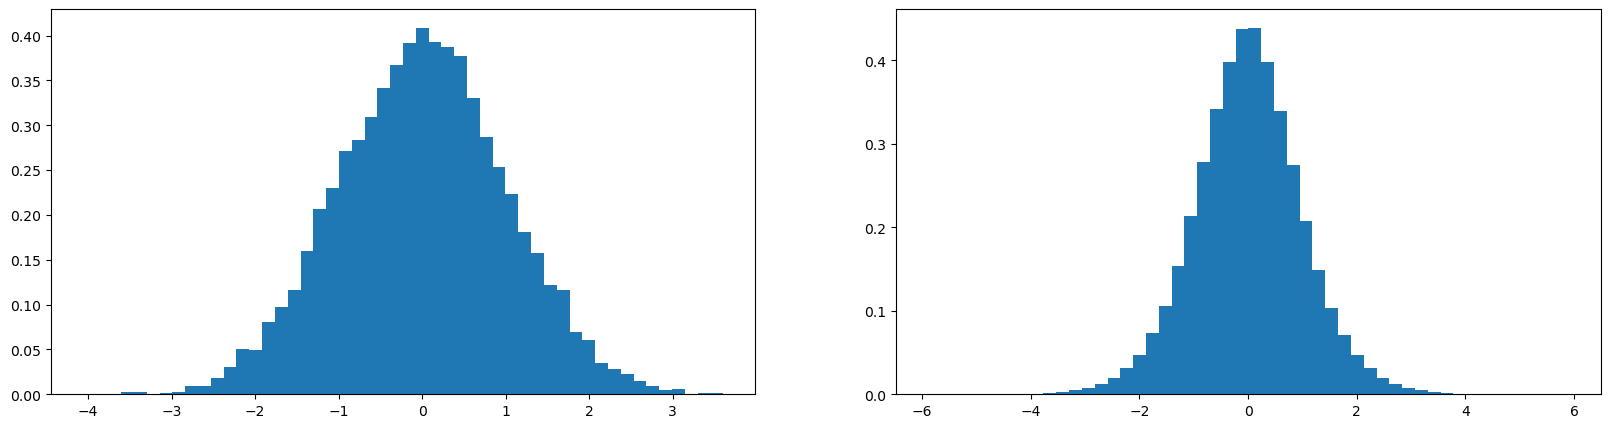

In [63]:
x =torch.randn(1000,10) 
w=torch.randn(10,200) /10**0.5
y=x@w 
print(x.mean(), x.std()) 
print(y.mean(), y.std()) 
plt.figure(figsize=(20,5)) 
plt.subplot(121) 
plt.hist(x.view(-1).tolist(),50,density=True) 
plt.subplot(122) 
plt.hist(y.view(-1).tolist(),50,density=True)